In [5]:
# paso 1:importar las librerías necesarias y cargar el dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Cargar el dataset
url = "https://raw.githubusercontent.com/4GeeksAcademy/data-preprocessing-project-tutorial/main/AB_NYC_2019.csv"
df_raw = pd.read_csv(url)

# Mostrar las primeras filas
print(df_raw.info())

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [6]:
# 2.Análisis Exploratorio de Datos (EDA)
# se eliminan columnas irrelevantes
# 'id', 'name', 'host_id', 'host_name' son etiquetas
df_processed = df_raw.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])

# hay valores nulos en el nuevo dataframe?
print("Valores nulos por columna:")
print(df_processed.isnull().sum())

# verificar el resumen estadístico de los precios
print("\nResumen de la columna Price:")
print(df_processed['price'].describe())

Valores nulos por columna:
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Resumen de la columna Price:
count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


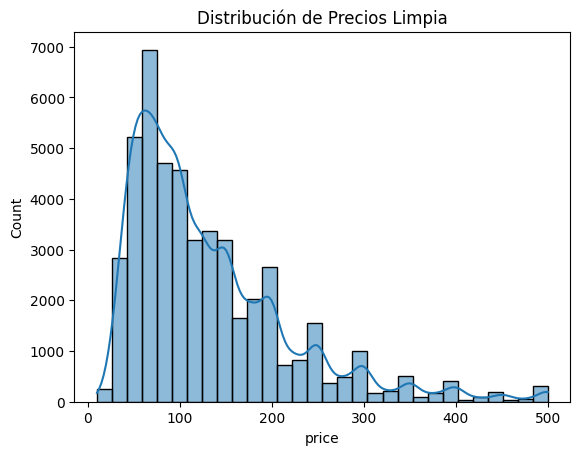

Set de entrenamiento: (38272, 10)
Set de prueba: (9568, 10)


In [7]:
# 2.1. Limpieza de datos faltantes 
# Como detectamos que hay 10,052 nulos en reviews_per_month, los llenamos con 0
df_processed['reviews_per_month'] = df_processed['reviews_per_month'].fillna(0)

# 2.2. Tratamiento de Outliers (Precios) 
# Según el resumen estadístico, hay precios de 0 y de 10,000. 
# se filtra para que quede con un rango realista () entre 1 y 500)
df_processed = df_processed[(df_processed['price'] > 0) & (df_processed['price'] <= 500)]

# 2.3. Visualización rápida (encontré en internet que es recomendado para un EDA) 
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df_processed['price'], bins=30, kde=True)
plt.title('Distribución de Precios Limpia')
plt.show()

#  2.4. División del dataset 
from sklearn.model_selection import train_test_split

# se separan las características (X) del objetivo (y)
X = df_processed.drop('price', axis=1)
y = df_processed['price']

# se dividen en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Set de entrenamiento: {X_train.shape}")
print(f"Set de prueba: {X_test.shape}")

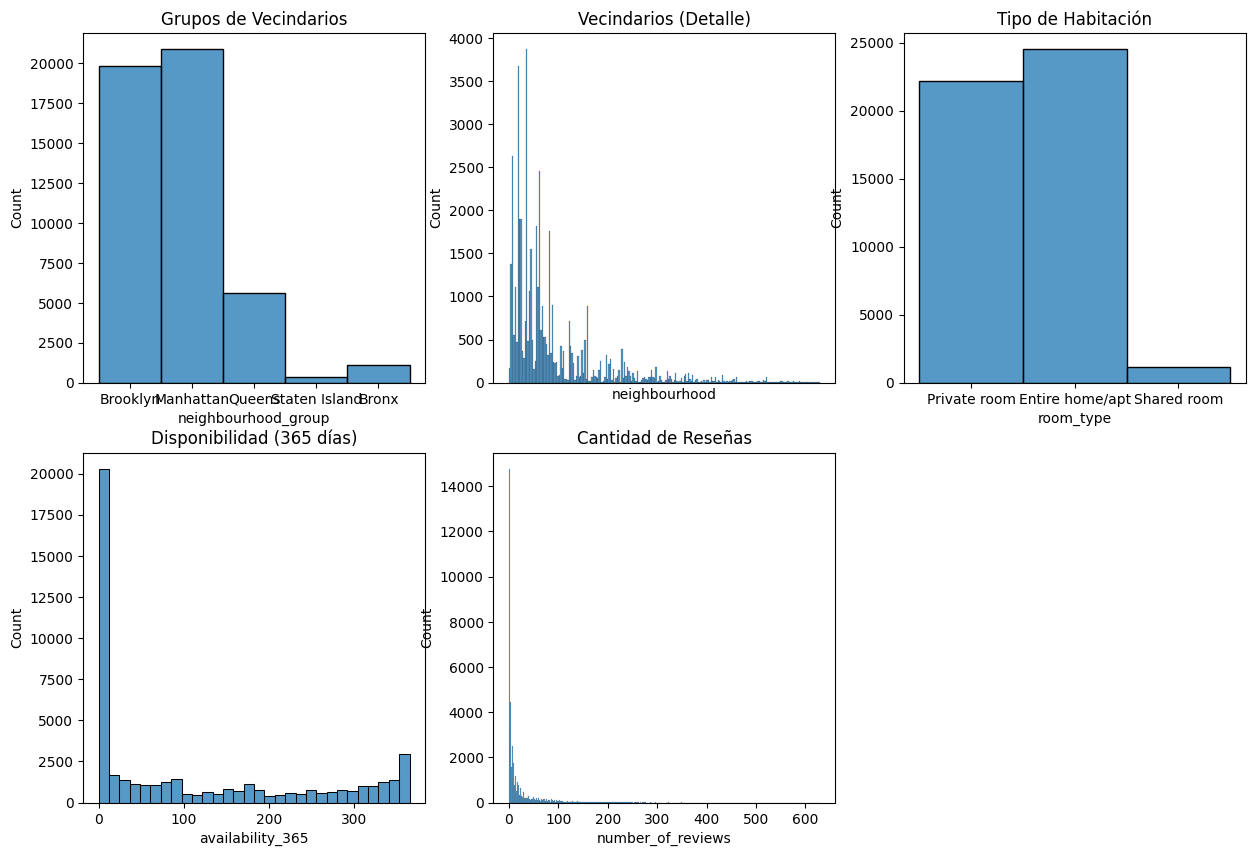

In [8]:
# Paso 3: Análisis de variables univariadas 
import matplotlib.pyplot as plt 
import seaborn as sns

# se crea una cuadrícula de 2 filas y 3 columnas
fig, axis = plt.subplots(2, 3, figsize=(15, 10))

# 1.distribucion de los grupos de vecindarios
sns.histplot(ax = axis[0,0], data = df_processed, x = "neighbourhood_group")
axis[0,0].set_title("Grupos de Vecindarios")

# 2. Vecindarios 
sns.histplot(ax = axis[0,1], data = df_processed, x = "neighbourhood").set_xticks([])
axis[0,1].set_title("Vecindarios (Detalle)")

# 3. Tipo de habitación
sns.histplot(ax = axis[0,2], data = df_processed, x = "room_type")
axis[0,2].set_title("Tipo de Habitación")

# 4. Disponibilidad al año
sns.histplot(ax = axis[1,0], data = df_processed, x = "availability_365")
axis[1,0].set_title("Disponibilidad (365 días)")

# 5. Número de reseñas 
sns.histplot(ax = axis[1,1], data = df_processed, x = "number_of_reviews")
axis[1,1].set_title("Cantidad de Reseñas")

# Ajustar diseño
plt.tight_layout

# Eliminamos el último espacio que sobra (fila 1, columna 2) me di cuenta que no tengo más variables categóricas para mostrar, así que elimino ese espacio vacío
fig.delaxes(axis[1, 2])

# Mostramos el gráfico
plt.show()




1. Grupos de Vecindarios: Se observa una dominancia de Brooklyn y Manhattan. Staten Island aparece como el grupo con menor representación, lo que indica que el mercado de Airbnb está fuertemente centralizado en las zonas más turísticas y densas de la ciudad.

2. Vecindarios: Aunque hay muchos barrios, el histograma muestra unos pocos picos muy altos, lo que sugiere que una pequeña cantidad de vecindarios específicos concentran la gran mayoría de la oferta.

3. Tipo de Habitación: La mayoría de las ofertas son Entire home/apt (Casas/Aptos enteros) o Private room (Habitaciones privadas). Las habitaciones compartidas (Shared rooms) casi no estan presentes en comparación, lo que refleja la preferencia de los usuarios por la privacidad.

4. Disponibilidad (365 días): Existe una distribución rara, hay un pico masivo cerca del 0 (alojamientos que casi nunca están disponibles) y otro pico menor cerca de 365 (alojamientos dedicados exclusivamente al alquiler vacacional todo el año).

5. Cantidad de Reseñas: La mayoría de los anuncios tienen pocas reseñas (concentradas cerca del 0).

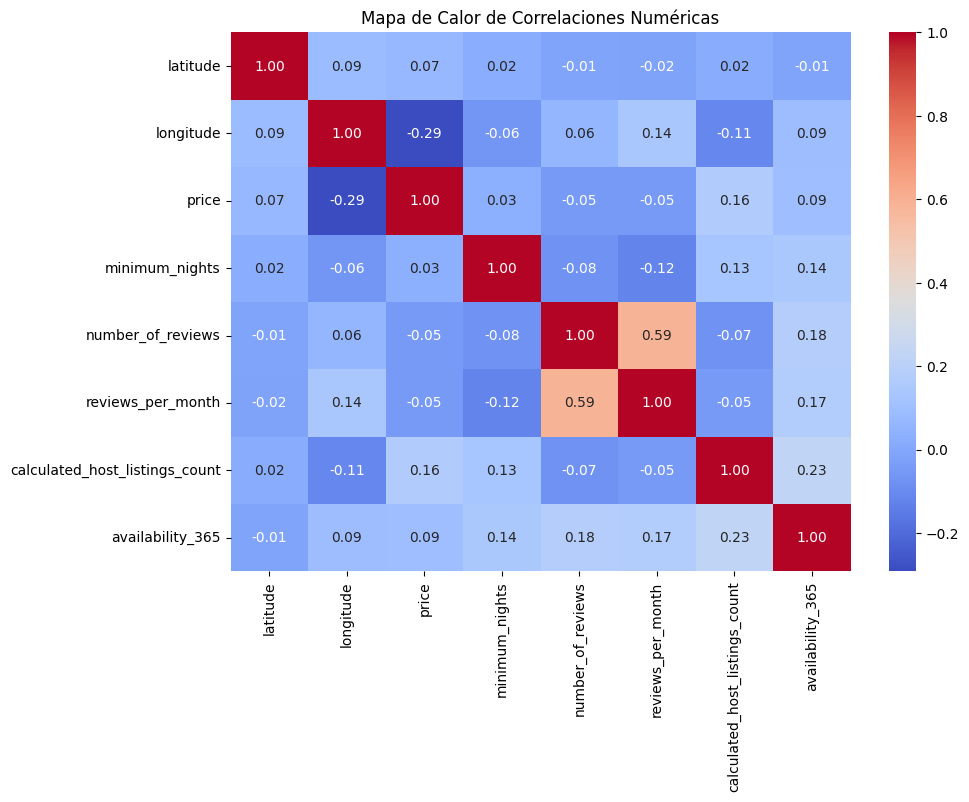

In [9]:
#analisis numerico-numerico
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 7))
sns.heatmap(df_processed.select_dtypes(include=['float64', 'int64']).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de Calor de Correlaciones Numéricas")
plt.show()


/tmp/ipykernel_5605/2413777524.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axis[0], data=df_processed, x="neighbourhood_group", y="price", palette="viridis")
/tmp/ipykernel_5605/2413777524.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axis[1], data=df_processed, x="room_type", y="price", palette="magma")


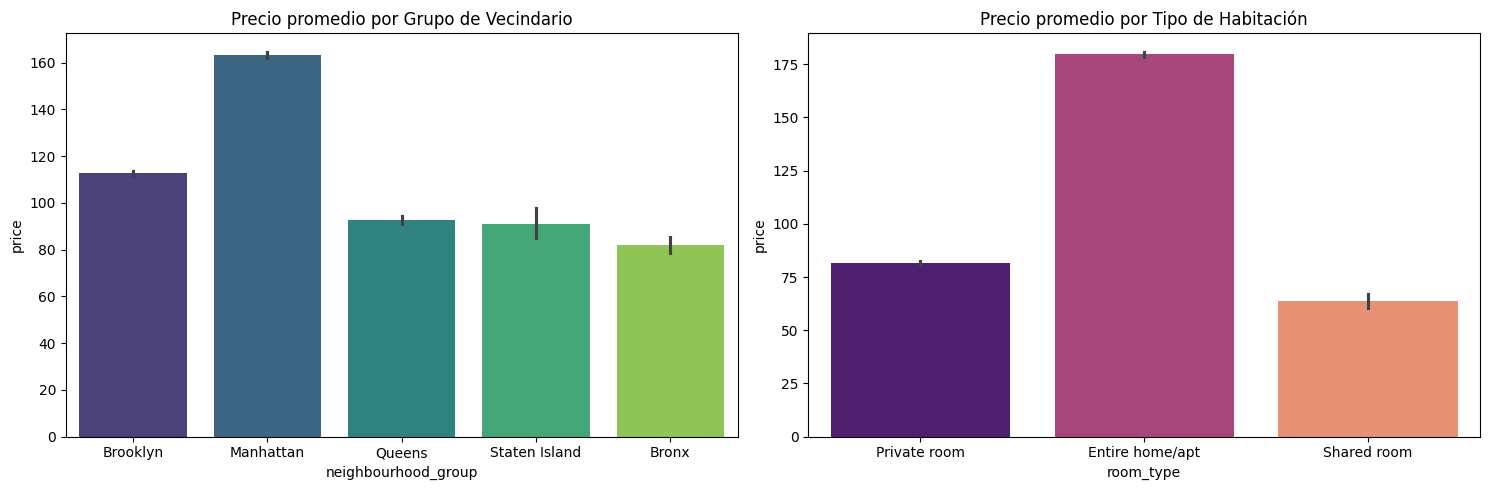

In [10]:
# analisis numerico-categorico
import matplotlib.pyplot as plt
import seaborn as sns
fig, axis = plt.subplots(1, 2, figsize=(15, 5))

# Precio vs Grupo de Vecindario
sns.barplot(ax=axis[0], data=df_processed, x="neighbourhood_group", y="price", palette="viridis")
axis[0].set_title("Precio promedio por Grupo de Vecindario")

# Precio vs Tipo de Habitación
sns.barplot(ax=axis[1], data=df_processed, x="room_type", y="price", palette="magma")
axis[1].set_title("Precio promedio por Tipo de Habitación")

plt.tight_layout()
plt.show()




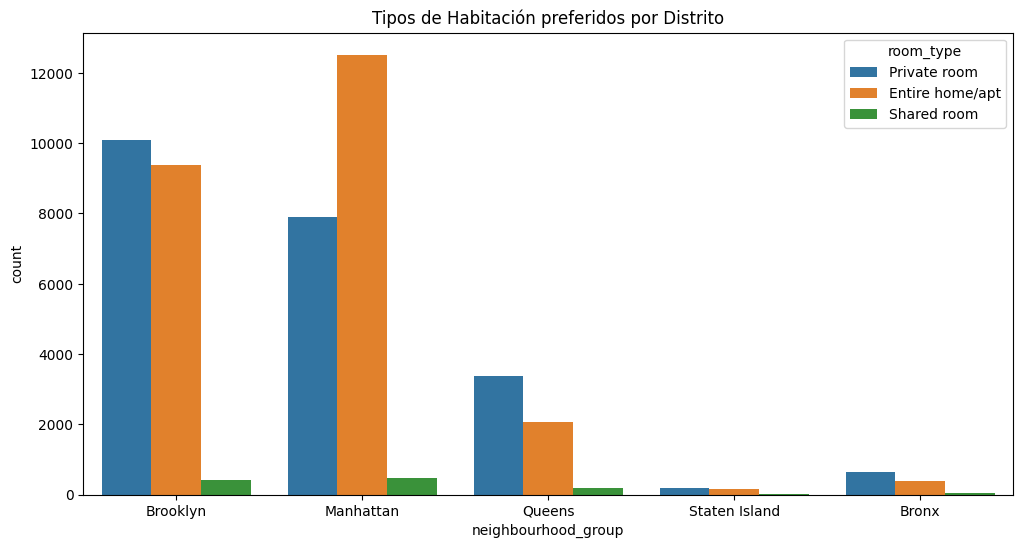

In [11]:
# analisis categorico-categorico
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=df_processed, x="neighbourhood_group", hue="room_type")
plt.title("Tipos de Habitación preferidos por Distrito")
plt.show()

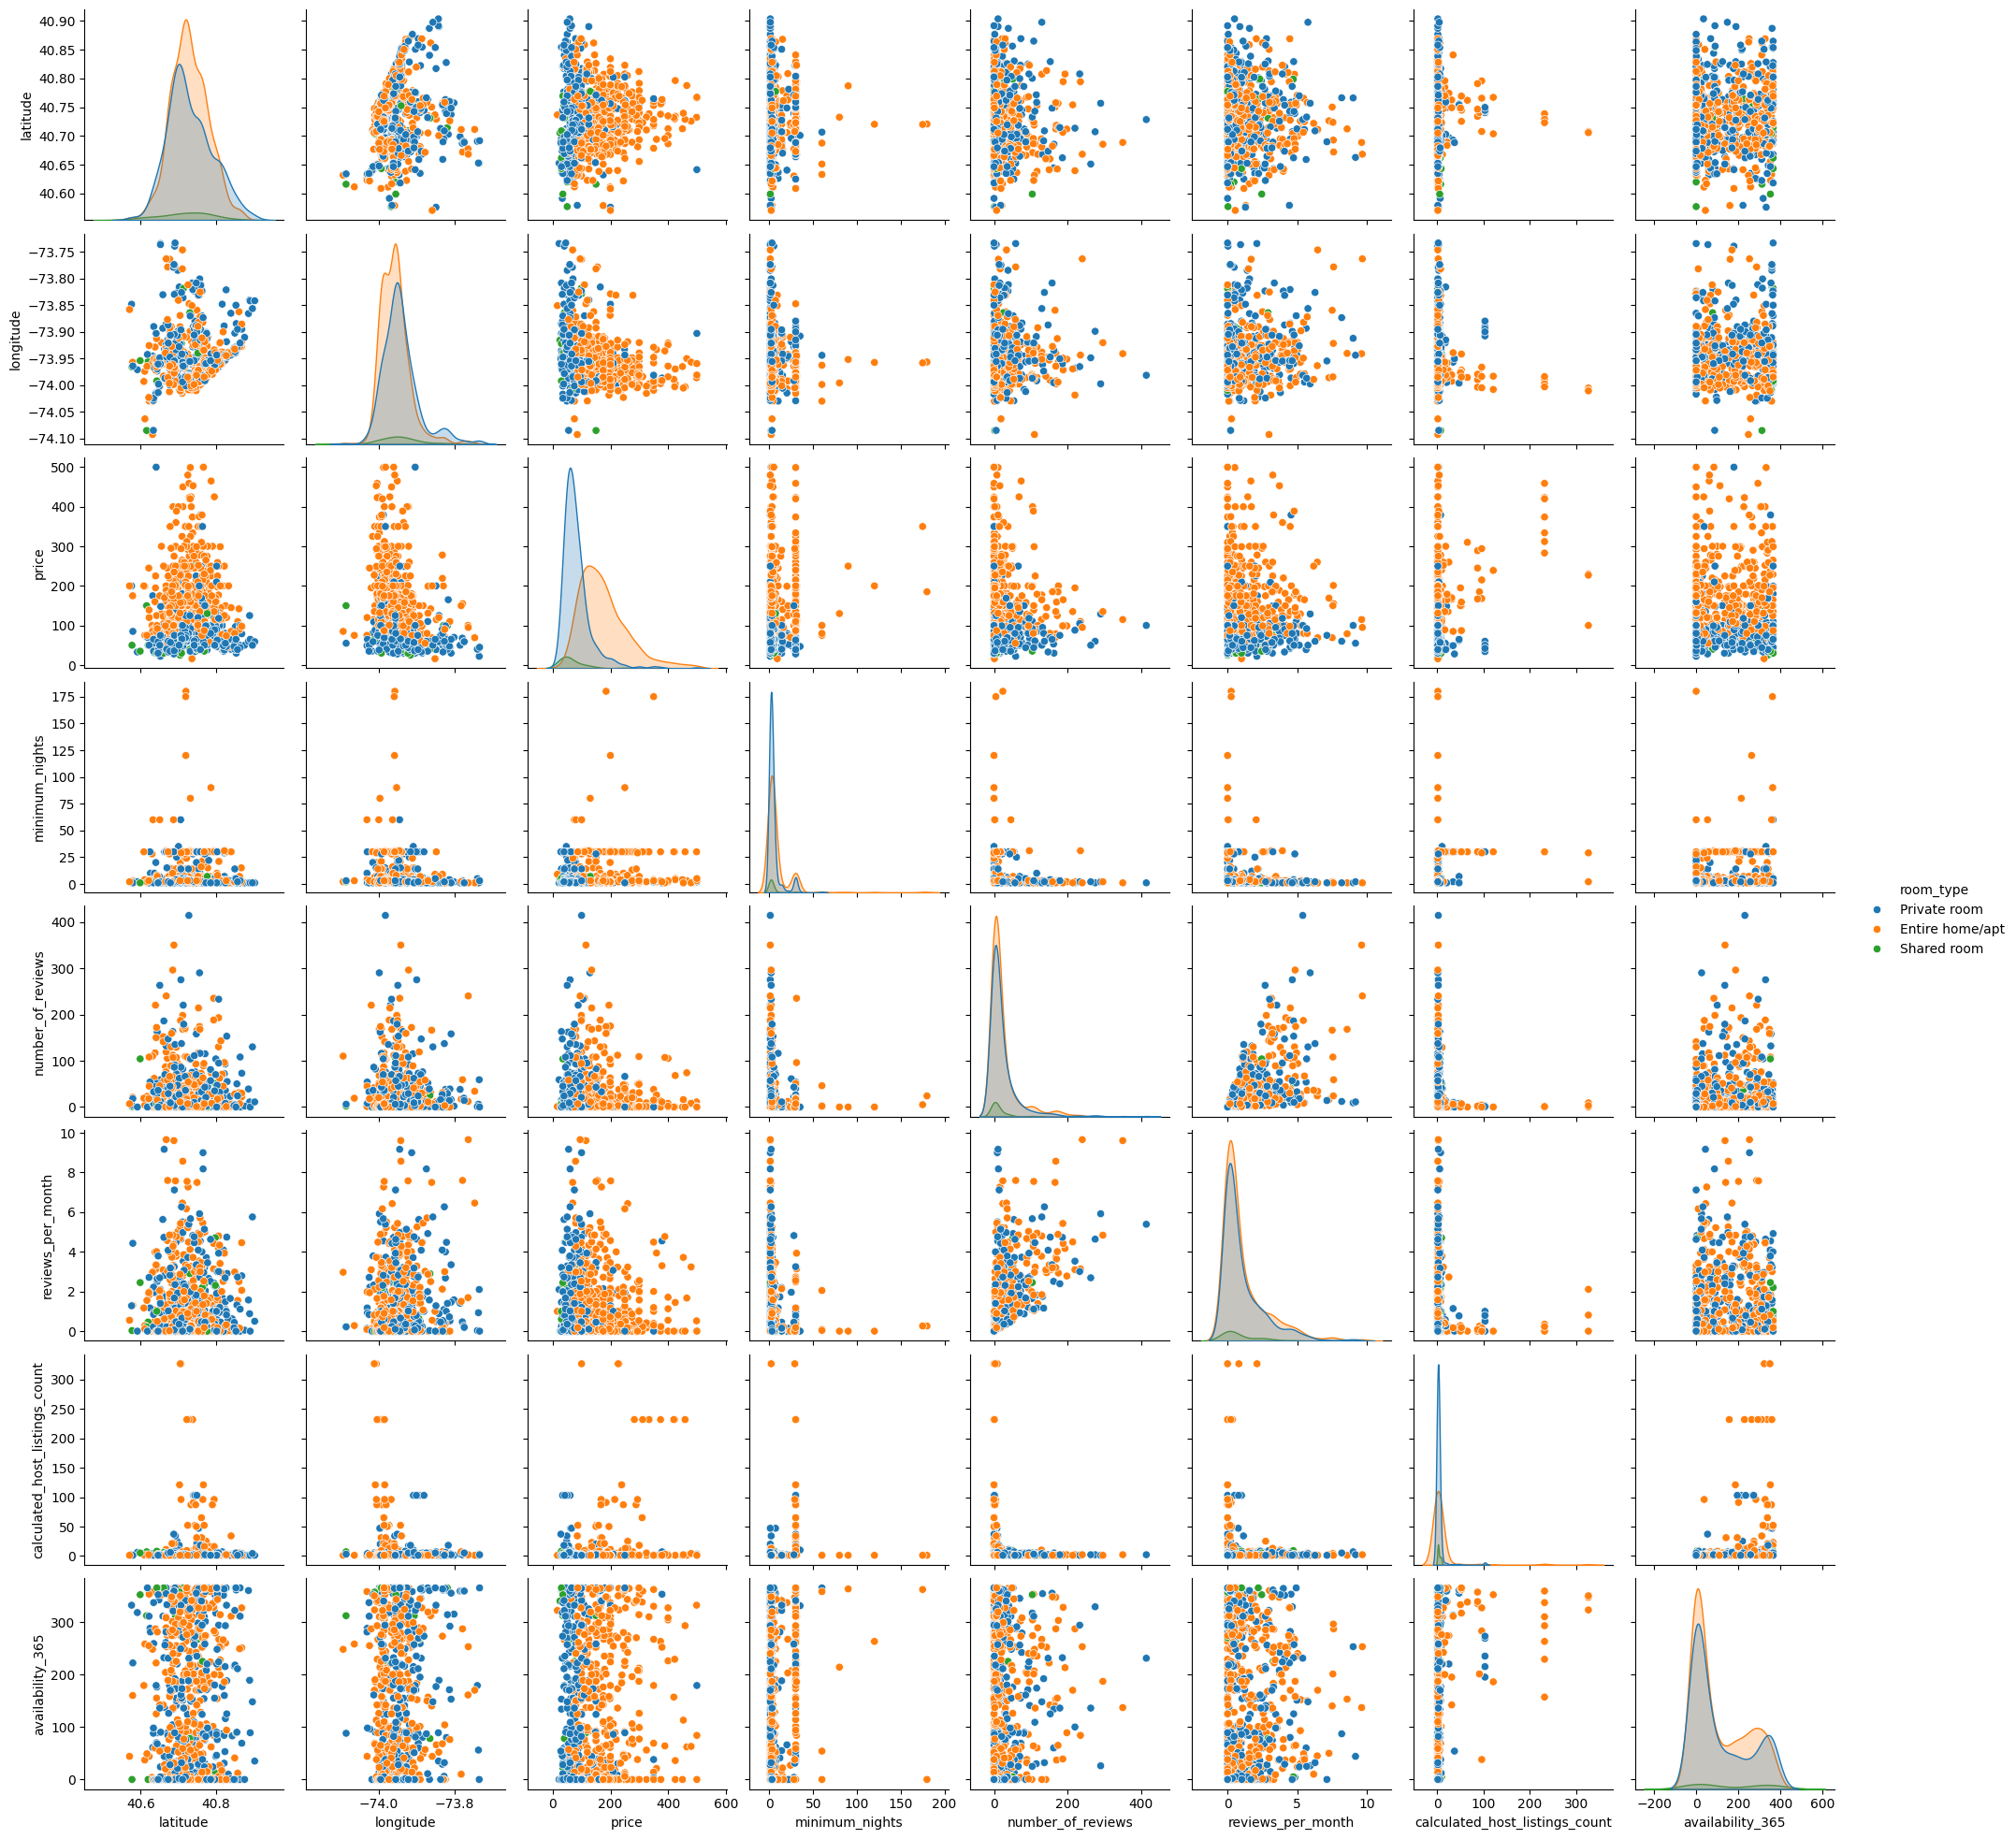

In [12]:
# Analizar todo a la vez
sns.pairplot(data=df_processed.sample(1000), hue="room_type")
plt.show()

In [13]:
# 5 ingieneria de funciones
# 1.analisis de valores atipicos
(df_raw.describe())

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


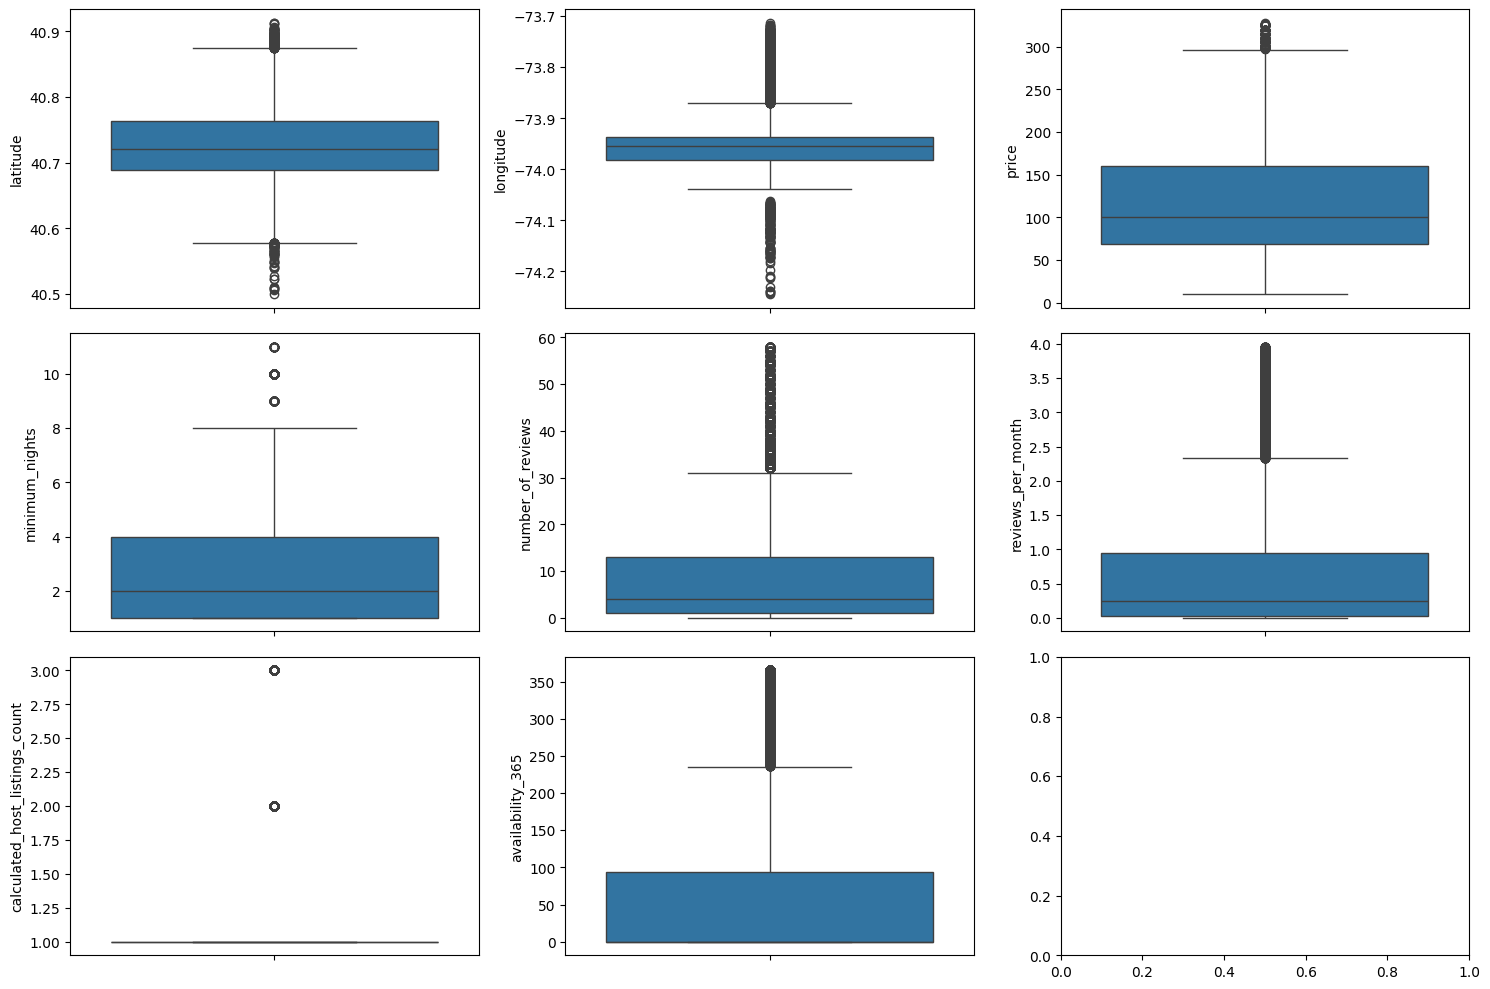

In [14]:
# 1 se generan las estadísticas descriptivas del dataset
stats = df_processed.describe()

# 2. el bucle para limpiar los outliers
for col in ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']:
    stats_col = stats[col]
    
    # se calcula el IQR (Rango Intercuartílico)
    iqr = stats_col['75%'] - stats_col['25%']
    upper_limit = stats_col['75%'] + 1.5 * iqr
    lower_limit = stats_col['25%'] - 1.5 * iqr
    
    #  se filtra el dataframe
    df_processed = df_processed[(df_processed[col] >= lower_limit) & (df_processed[col] <= upper_limit)]

# 3. se dibujan los boxplots después de la limpieza para mostrar el resultado
fig, axis = plt.subplots(3, 3, figsize = (15, 10))

sns.boxplot(ax = axis[0, 0], data = df_processed, y = "latitude")
sns.boxplot(ax = axis[0, 1], data = df_processed, y = "longitude")
sns.boxplot(ax = axis[0, 2], data = df_processed, y = "price")
sns.boxplot(ax = axis[1, 0], data = df_processed, y = "minimum_nights")
sns.boxplot(ax = axis[1, 1], data = df_processed, y = "number_of_reviews")
sns.boxplot(ax = axis[1, 2], data = df_processed, y = "reviews_per_month")
sns.boxplot(ax = axis[2, 0], data = df_processed, y = "calculated_host_listings_count")
sns.boxplot(ax = axis[2, 1], data = df_processed, y = "availability_365")

plt.tight_layout()
plt.show()


In [15]:
# Stats for Price
price_stats = df_processed["price"].describe()
price_stats


count    29723.000000
mean       120.850755
std         66.918271
min         10.000000
25%         69.000000
50%        100.000000
75%        160.000000
max        328.000000
Name: price, dtype: float64

In [16]:
# IQR para Price

price_iqr = price_stats["75%"] - price_stats["25%"]
upper_limit = price_stats["75%"] + 1.5 * price_iqr
lower_limit = price_stats["25%"] - 1.5 * price_iqr

print(f"el limite superior e inferior para encontrar valores atípicos son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un intercuartil de {round(price_iqr, 2)}")

el limite superior e inferior para encontrar valores atípicos son 296.5 y -67.5, con un intercuartil de 91.0


In [21]:
# limpieza de outliers

total_data = df_raw[df_raw["price"] > 0]

In [22]:
count_0 = total_data[total_data["price"] == 0].shape[0]
count_1 = total_data[total_data["price"] == 1].shape[0]

print("Count of 0: ", count_0)
print("Count of 1: ", count_1)

Count of 0:  0
Count of 1:  0


##### Detección de valores atípicos (outliers) para minimum_nights

In [ ]:
nights_stats = total_data["minimum_nights"].describe()
nights_stat

count    48884.000000
mean         7.029887
std         20.512224
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max       1250.000000
Name: minimum_nights, dtype: float64

In [25]:
# IQR for minimum_nights
nights_iqr = nights_stats["75%"] - nights_stats["25%"]

upper_limit = nights_stats["75%"] + 1.5 * nights_iqr
lower_limit = nights_stats["25%"] - 1.5 * nights_iqr

print(f"Los límites superior e inferior para encontrar valores atípicos {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(nights_iqr, 2)}")

Los límites superior e inferior para encontrar valores atípicos 11.0 y -5.0, con un rango intercuartílico de 4.0


In [26]:
# limpieza de outliers

total_data = total_data[total_data["minimum_nights"] <= 15]

In [27]:
count_0 = total_data[total_data["minimum_nights"] == 0].shape[0]
count_1 = total_data[total_data["minimum_nights"] == 1].shape[0]
count_2 = total_data[total_data["minimum_nights"] == 2].shape[0]
count_3 = total_data[total_data["minimum_nights"] == 3].shape[0]
count_4 = total_data[total_data["minimum_nights"] == 4].shape[0]


print("Count of 0: ", count_0)
print("Count of 1: ", count_1)
print("Count of 2: ", count_2)
print("Count of 3: ", count_3)
print("Count of 4: ", count_4)

Count of 0:  0
Count of 1:  12717
Count of 2:  11693
Count of 3:  7998
Count of 4:  3302


##### Detección de valores atipicos (outliers) para number_of_reviews

In [29]:
# estadísticas para number_of_reviews

review_stats = total_data["number_of_reviews"].describe()
review_stats

count    43265.000000
mean        25.211950
std         46.292011
min          0.000000
25%          1.000000
50%          6.000000
75%         27.000000
max        629.000000
Name: number_of_reviews, dtype: float64

In [31]:
# IQR para number_of_reviews

review_iqr = review_stats["75%"] - review_stats["25%"]

upper_limit = review_stats["75%"] + 1.5 * review_iqr
lower_limit = review_stats["25%"] - 1.5 * review_iqr

print(f"Los límites superior e inferior para encontrar valores atípicos {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(review_iqr, 2)}")

Los límites superior e inferior para encontrar valores atípicos 66.0 y -38.0, con un rango intercuartílico de 26.0


## Detección de valores atípicos para calculated_host_listings_count

In [32]:
# Estadísticas para calculated_host_listings_count

hostlist_stats = total_data["calculated_host_listings_count"].describe()
hostlist_stats

count    43265.000000
mean         3.369305
std         21.721688
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        327.000000
Name: calculated_host_listings_count, dtype: float64

In [33]:
# IQR para calculated_host_listings_count

hostlist_iqr = hostlist_stats["75%"] - hostlist_stats["25%"]

upper_limit = hostlist_stats["75%"] + 1.5 * hostlist_iqr
lower_limit = hostlist_stats["25%"] - 1.5 * hostlist_iqr

print(f"Los límites superior e inferior para encontrar valores atípicos {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartílico de {round(hostlist_iqr, 2)}")

Los límites superior e inferior para encontrar valores atípicos 3.5 y -0.5, con un rango intercuartílico de 1.0


In [34]:
count_04 = sum(1 for x in total_data["calculated_host_listings_count"] if x in range(0, 5))
count_1 = total_data[total_data["calculated_host_listings_count"] == 1].shape[0]
count_2 = total_data[total_data["calculated_host_listings_count"] == 2].shape[0]

print("Count of 0: ", count_04)
print("Count of 1: ", count_1)
print("Count of 2: ", count_2)

Count of 0:  40308
Count of 1:  30253
Count of 2:  6179


In [35]:
# limpieza de los outliers

total_data = total_data[total_data["calculated_host_listings_count"] > 4]

## Analisis de valores nulos

In [37]:
# Contar NaN
total_data.isnull().sum().sort_values(ascending = False)

last_review                       442
reviews_per_month                 442
name                                1
id                                  0
neighbourhood_group                 0
neighbourhood                       0
host_id                             0
host_name                           0
longitude                           0
latitude                            0
room_type                           0
price                               0
number_of_reviews                   0
minimum_nights                      0
calculated_host_listings_count      0
availability_365                    0
dtype: int64

#### Feature scaling

In [40]:
from sklearn.preprocessing import MinMaxScaler

# se Convierte el texto a números 
total_data["neighbourhood_group"] = pd.factorize(total_data["neighbourhood_group"])[0]
total_data["room_type"] = pd.factorize(total_data["room_type"])[0]

# usar codigo original para evitar errores de variables no definidas
num_variables = ["number_of_reviews", "minimum_nights", "calculated_host_listings_count", 
                 "availability_365", "neighbourhood_group", "room_type"]

scaler = MinMaxScaler()
scal_features = scaler.fit_transform(total_data[num_variables])

# se crea el DataFrame final
df_scal = pd.DataFrame(scal_features, index = total_data.index, columns = num_variables)
df_scal["price"] = total_data["price"]

df_scal.head()

num_variables = ["number_of_reviews", "minimum_nights", "calculated_host_listings_count", 
                 "availability_365", "neighbourhood_group", "room_type"]
scaler = MinMaxScaler()
scal_features = scaler.fit_transform(total_data[num_variables])
df_scal = pd.DataFrame(scal_features, index = total_data.index, columns = num_variables)
df_scal["price"] = total_data["price"]
df_scal.head()

,number_of_reviews,minimum_nights,calculated_host_listings_count,availability_365,neighbourhood_group,room_type,price
0,0.016575,0.000000,0.003106,1.000000,0.0,0.0,149
21,0.239411,0.071429,0.003106,0.950685,0.0,0.0,130
22,0.071823,0.000000,0.003106,0.997260,0.0,0.0,80
23,0.130755,0.071429,0.003106,0.832877,0.0,0.0,110
92,0.029466,0.428571,0.003106,0.506849,0.0,0.0,98


## Feature Selection (seleccion de variables)

In [41]:
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.model_selection import train_test_split

X = df_scal.drop("price", axis = 1)
y = df_scal["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


selection_model = SelectKBest(chi2, k = 4)
selection_model.fit(X_train, y_train)
ix = selection_model.get_support()
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = X_train.columns.values[ix])
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = X_test.columns.values[ix])

X_train_sel.head()

,minimum_nights,calculated_host_listings_count,neighbourhood_group,room_type
0,0.000000,0.000000,0.00,0.0
1,0.071429,1.000000,0.50,0.5
2,0.071429,0.000000,0.25,0.0
3,0.428571,0.130435,0.50,0.0
4,0.071429,1.000000,0.50,0.5


In [43]:
import os

# se Crea la ruta (si no existe)
path = "../data/processed"
if not os.path.exists(path):
    os.makedirs(path)

# guardar los archivos CSV
X_train_sel.to_csv("../data/processed/clean_train.csv", index = False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index = False)


X_train_sel["price"] = list(y_train)
X_test_sel["price"] = list(y_test)
X_train_sel.to_csv("../data/processed/clean_train.csv", index = False)
X_test_sel.to_csv("../data/processed/clean_test.csv", index = False)